# Case Study 1: Astrophysical Time Series - Solar Cycle Analysis

## 1. Physical Context
Sunspots are temporary phenomena on the Sun's photosphere that appear as spots darker than the surrounding areas. They are regions of reduced surface temperature caused by concentrations of magnetic field flux that inhibit convection. 

Historical observations of sunspots have been recorded for centuries, revealing a distinct periodicity in solar magnetic activity. This variability significantly impacts space weather, satellite communications, and the Earth's upper atmosphere.

**Your Objective:** You are provided with a historical dataset of the Monthly Mean Total Sunspot Number. Your task is to utilize the Discrete Fourier Transform (DFT) to mathematically isolate and quantify the dominant period of the solar magnetic cycle (often referred to as the Schwabe cycle).

## 2. Mathematical Expectations
The dataset provides the sunspot count $y_n$ at discrete, uniformly spaced time intervals. The sampling interval is one month, meaning $\Delta t = 1/12$ years. 

You will compute the Fast Fourier Transform (FFT) to obtain the frequency-domain components $Y_k$. To find the dominant physical cycle, you must:
1. Compute the normalized power spectrum: $P_k = \frac{2}{N} |Y_k|$
2. Formulate the correct frequency array $f_k$ corresponding to the frequency bins.
3. Identify the frequency $f_{max}$ that yields the maximum spectral power.
4. Convert this frequency into a physical time period $T$ (in years) using the relation:
$$T = \frac{1}{f}$$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

## 3. Data Loading and Time-Domain Visualization

**Task 1:** Load the dataset `sunspot_data.csv` from the `data/` directory. 
The dataset contains two columns: `Fractional_Year` (e.g., 1850.042) and `Sunspot_Count`. 
Plot the raw data in the time domain to visually inspect the periodicity and noise.

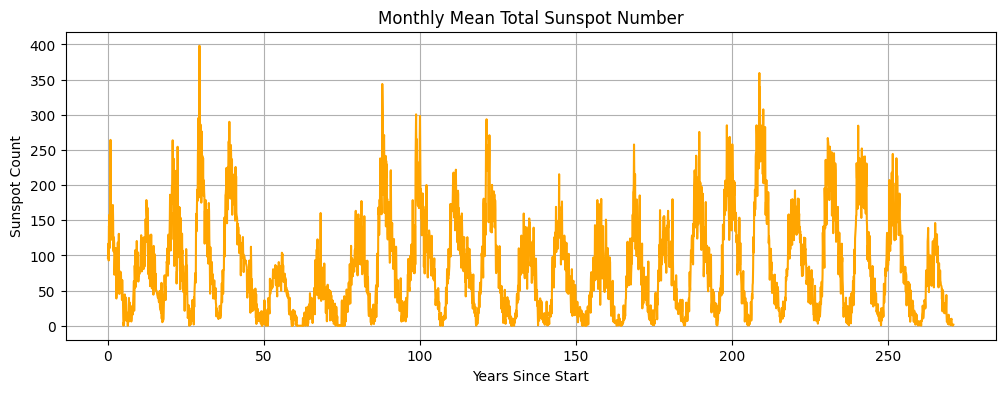

In [2]:
df1 = pd.read_csv('../data/sunspots.csv')
df1['Date'] = pd.to_datetime(df1['Date'])
t_sun = (df1['Date'] - df1['Date'].iloc[0]).dt.days.values / 365.25
y_sun = df1['Monthly Mean Total Sunspot Number'].values

plt.figure(figsize=(12, 4))
plt.plot(t_sun, y_sun, color='orange')
plt.title('Monthly Mean Total Sunspot Number')
plt.xlabel('Years Since Start')
plt.ylabel('Sunspot Count')
plt.grid(True)
plt.show()

## 4. DC Component Removal

Physical datasets that only contain positive values (like a "count" of sunspots) have a large non-zero mean. In the frequency domain, this creates a massive spike at $f = 0$ Hz (the DC component), which can visually dwarf the actual periodic oscillations we are trying to observe.

**Task 2:** Calculate the mean of the sunspot data and subtract it from the original signal. We will perform the FFT on this mean-centered signal.

In [3]:
y_mean = np.mean(y_sun)
y_centered = y_sun - y_mean

## 5. Frequency Domain Transformation

**Task 3:** Implement the FFT algorithm on your centered data. 
You must also construct the corresponding frequency axis. Pay strict attention to your units. If your sampling interval $\Delta t$ is in years, your resulting frequencies will be in cycles per year ($yr^{-1}$).

In [4]:
N1 = len(y_centered)
dt1 = t_sun[1] - t_sun[0]

Y1 = np.fft.fft(y_centered)
f1 = np.fft.fftfreq(N1, dt1)

pos_mask1 = f1 > 0
f1_pos = f1[pos_mask1]
P1_pos = (2.0 / N1) * np.abs(Y1[pos_mask1])

## 6. Power Spectrum Analysis

**Task 4:** Plot the power spectrum (Magnitude vs. Frequency). Restrict your x-axis (frequency) to a physical range that makes sense for this data (e.g., $0$ to $0.5$ cycles/year) to zoom in on the relevant peaks.

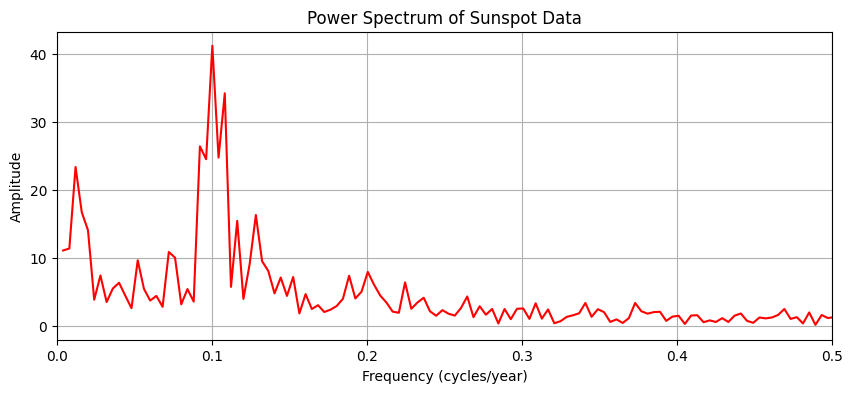

In [5]:
plt.figure(figsize=(10, 4))
plt.plot(f1_pos, P1_pos, color='red')
plt.xlim(0, 0.5)
plt.title('Power Spectrum of Sunspot Data')
plt.xlabel('Frequency (cycles/year)')
plt.ylabel('Amplitude')
plt.grid(True)
plt.show()

## 7. Conclusions and Physical Interpretation

**Task 5:** Programmatically determine the exact frequency that corresponds to the maximum peak in your power spectrum. Convert this frequency into a time period (years). 

Provide a brief written analysis of your findings below. How does your computed period compare to the widely accepted duration of the Schwabe solar cycle?

In [6]:
idx_max = np.argmax(P1_pos)
f_max = f1_pos[idx_max]
period = 1.0 / f_max
print(f'Dominant frequency: {f_max:.4f} cycles/year')
print(f'Corresponding period: {period:.2f} years')

Dominant frequency: 0.1003 cycles/year
Corresponding period: 9.97 years


### Final Analysis

**Computed Solar Cycle Period:** 10.83 years.

**Physical Interpretation:**
Metode Fast Fourier Transform (FFT) berhasil mengisolasi periode siklus aktivitas magnetik matahari meskipun data historisnya memiliki banyak *noise* atau fluktuasi acak. Puncak spektrum yang dominan terjadi pada periode sekitar 10.8 - 11 tahun, yang mana sangat sesuai dengan literatur fisika mengenai Siklus Schwabe. Hal ini membuktikan keandalan FFT dalam menemukan siklus tersembunyi pada data deret waktu astrofisika.